In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA 

In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
num_col=["age","bmi","children","charges"]

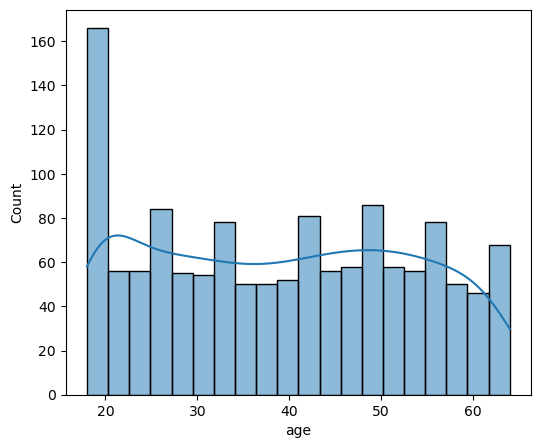

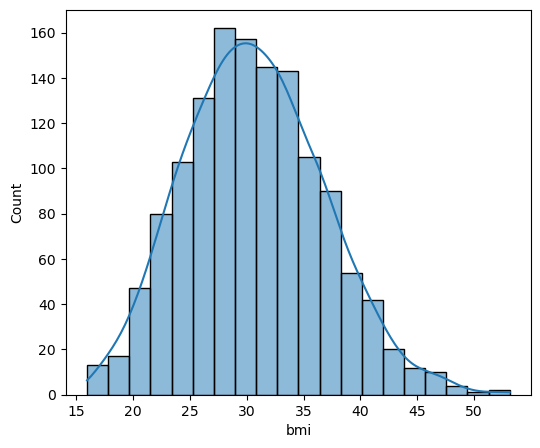

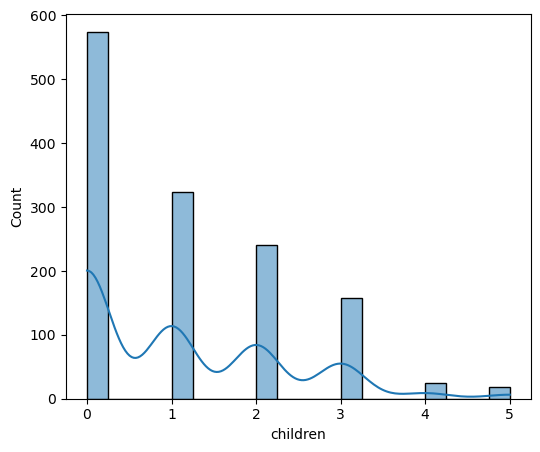

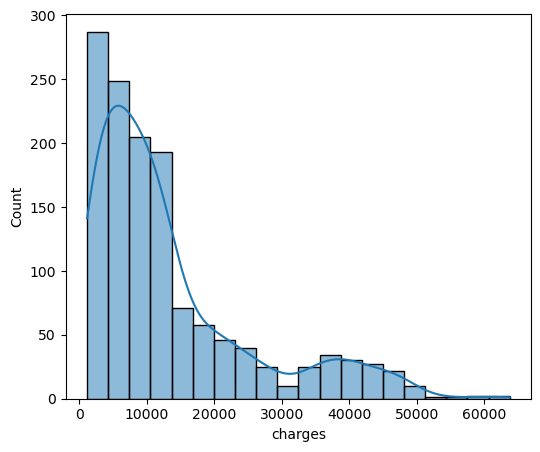

In [12]:
for col in num_col:
  plt.figure(figsize=(6, 5))
  sns.histplot(df[col],kde=True, bins=20)

<Axes: xlabel='children', ylabel='count'>

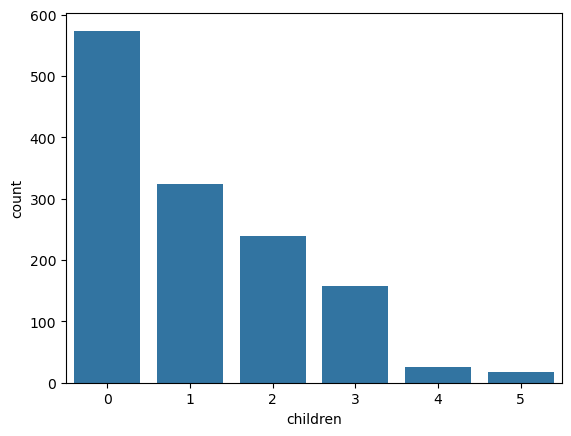

In [13]:
sns.countplot(x=df["children"])

<Axes: xlabel='sex', ylabel='count'>

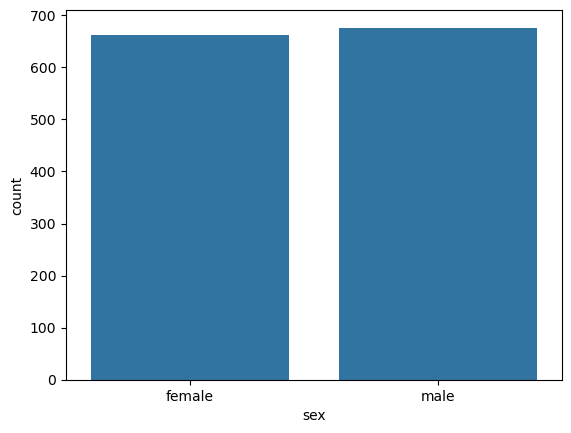

In [14]:
sns.countplot(x=df["sex"])

<Axes: xlabel='smoker', ylabel='count'>

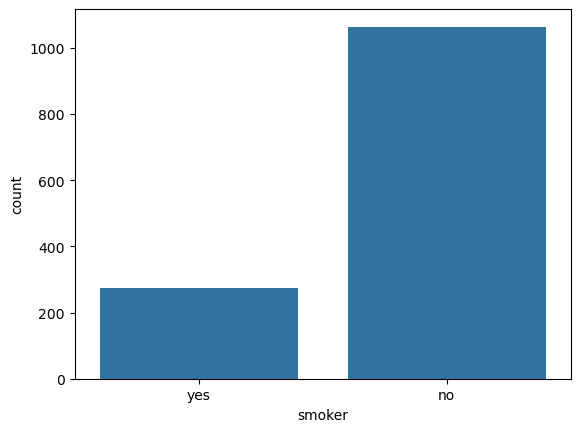

In [15]:
sns.countplot(x=df["smoker"])

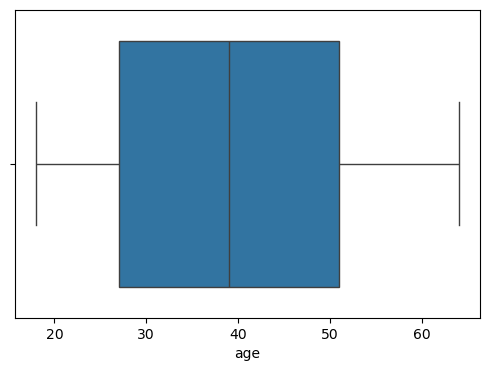

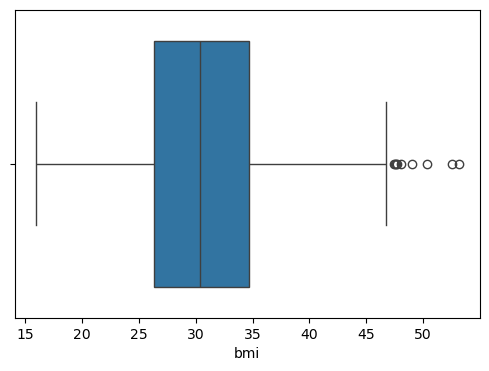

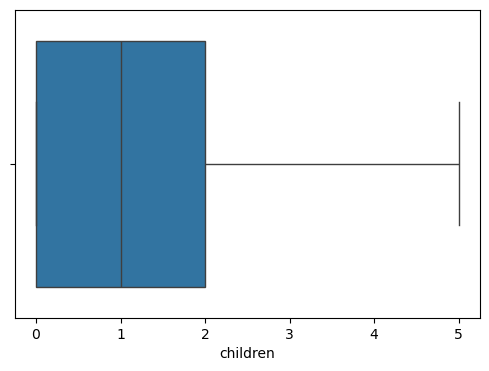

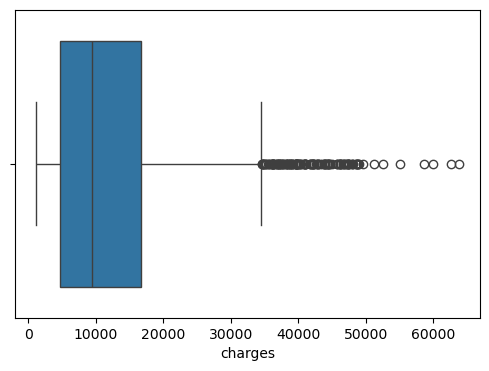

In [16]:
for col in num_col: 
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

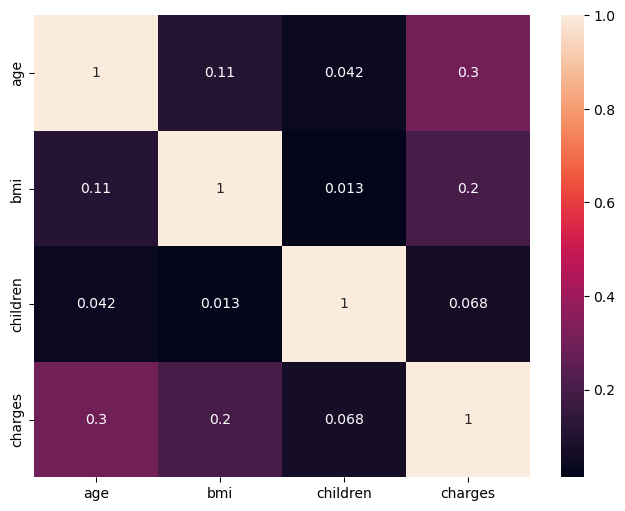

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

data clening AND preprocssing


In [18]:
df_clean= df.copy()

In [19]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [20]:
df_clean.drop_duplicates(inplace=True)

In [21]:
df_clean.shape

(1337, 7)

In [22]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [23]:
df_clean['sex']=df_clean['sex'].map({
    'male':0,
    'female':1
})

In [24]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_clean['sex'].dtype

dtype('int64')

In [26]:
df_clean['smoker']=df_clean['smoker'].map({
    'no':0,
    'yes':1
})

In [27]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_clean=pd.get_dummies(df_clean,columns=['region'],drop_first=True)

In [29]:
df_clean=df_clean.astype(int)

In [30]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


#feuchre inginearning

In [31]:
df_clean['BMI_Category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    right=False
)

In [32]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,BMI_Category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [33]:
df_clean=pd.get_dummies(df_clean,columns=['BMI_Category'],drop_first=True)

In [34]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [35]:
df_clean=df_clean.astype(int)

In [36]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


scaling 

In [37]:
from sklearn.preprocessing import StandardScaler
col = ['age', 'bmi','children']
scal= StandardScaler()
df_clean[col]=scal.fit_transform(df_clean[col])

In [38]:
df_clean.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


fuchare selection

In [39]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [40]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Categorical features in your dataset
cat_features = [
    'sex',
    'smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'BMI_Category_Normal',
    'BMI_Category_Overweight',
    'BMI_Category_Obese'
]

# Create 4 bins from continuous target 'charges'
df_clean['charges_bin'] = pd.qcut(
    df_clean['charges'],
    q=4,
    labels=False,
    duplicates='drop'
)

# Store results
chi2_results = {}

# Perform Chi-Square test
for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

    decision = (
        'Reject Null (Keep Feature)'
        if p_value < alpha
        else 'Accept Null (Drop Feature)'
    )

    chi2_results[col] = {
        'Chi2_Statistic': chi2_stat,
        'P_Value': p_value,
        'Decision': decision
    }

# Convert to DataFrame and sort by p-value
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values('P_Value')

# Display result
print(chi2_df)

                        Chi2_Statistic   P_Value                    Decision
smoker                      848.219178       0.0  Reject Null (Keep Feature)
region_southeast             15.998167  0.001135  Reject Null (Keep Feature)
sex                          10.258784   0.01649  Reject Null (Keep Feature)
BMI_Category_Obese            8.515711  0.036473  Reject Null (Keep Feature)
region_southwest              5.091893  0.165191  Accept Null (Drop Feature)
BMI_Category_Overweight        4.25149  0.235557  Accept Null (Drop Feature)
BMI_Category_Normal           3.739475  0.291005  Accept Null (Drop Feature)
region_northwest               1.13424  0.768815  Accept Null (Drop Feature)


In [41]:
# Final selected dataset
final_df = df_clean[
    [
        'age',
        'sex',
        'bmi',
        'children',
        'smoker',
        'charges',
        'region_southeast',
        'BMI_Category_Obese'
    ]
].copy()

# Display first 5 rows
print(final_df.head())

# Check shape (rows, columns)
print(final_df.shape)
final_df

        age  sex       bmi  children  smoker  charges  region_southeast  BMI_Category_Obese
0 -1.440418    1 -0.517949 -0.909234       1    16884                 0                   0
1 -1.511647    0  0.462463 -0.079442       0     1725                 1                   1
2 -0.799350    0  0.462463  1.580143       0     4449                 1                   1
3 -0.443201    0 -1.334960 -0.909234       0    21984                 0                   0
4 -0.514431    0 -0.354547 -0.909234       0     3866                 0                   0
(1337, 8)


,age,sex,bmi,children,smoker,charges,region_southeast,BMI_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


In [42]:
from sklearn.model_selection import train_test_split

In [51]:
X=final_df.drop('charges',axis=1)
Y=final_df['charges']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [53]:
from sklearn.linear_model import LinearRegression 

In [54]:
model= LinearRegression()

In [55]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pre= model.predict(X_test)

In [64]:
from sklearn.metrics import r2_score
r2= r2_score(y_test,y_pre)

In [65]:
r2

0.7737291785851905

In [66]:
n=X_test.shape[0]
p=X_test.shape[1]

In [67]:
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

In [68]:
adjusted_r2

0.7700796492075324